### NYC Block-Level Analysis

This notebook prepares a block-level dataset for New York City for population, distance to water bodies, and distance to parks metrics. Population data was sourced frrom 2020 Census data from NHGIS. Census block geometries for New York State are filtered to the five NYC boroughs (Bronx, Brooklyn, Manhattan, Queens, and Staten Island) and joined with total population counts at the block level. Parks and Water bodies data were sourced from NYC Open Data. The resulting dataset is exported for use in future spatial analyses.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize
from scipy.ndimage import distance_transform_edt
from rasterstats import zonal_stats

<Axes: >

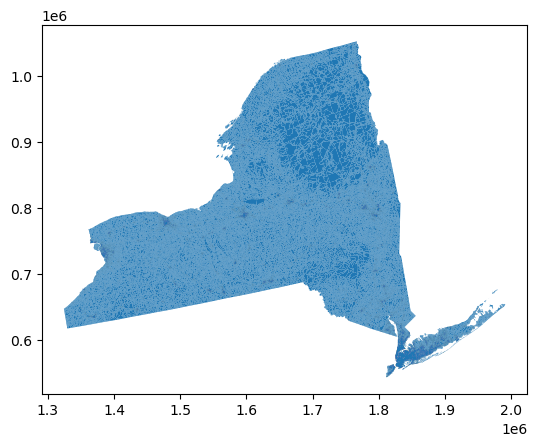

In [2]:
# Load and filter shapefile
NY_block_all = gpd.read_file("nhgis0003_shape/NY_block_2020.shp")
NY_block_all.plot()

In [3]:
NY_block_all.head(3)
print(NY_block_all.columns)

Index(['GISJOIN', 'STATEFP20', 'COUNTYFP20', 'TRACTCE20', 'BLOCKCE20',
       'GEOID20', 'NAME20', 'MTFCC20', 'UR20', 'UACE20', 'UATYPE20',
       'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object')


In [4]:
NY_block_all["COUNTYFP20"].dtype

dtype('O')

In [5]:
NYC_FIPS = ["005", "047", "061", "081", "085"]
BOROUGH_NAMES = {
    "005": "Bronx",
    "047": "Brooklyn",
    "061": "Manhattan",
    "081": "Queens",
    "085": "Staten Island",
}

In [6]:
nyc_blocks = NY_block_all[NY_block_all["COUNTYFP20"].isin(NYC_FIPS)].copy()
nyc_blocks["borough"] = nyc_blocks["COUNTYFP20"].map(BOROUGH_NAMES)

In [7]:
print(f"NYC blocks: {len(nyc_blocks):,}")

NYC blocks: 37,480


In [8]:
# Load population csv
population = pd.read_csv(
    "nhgis0003_csv/nhgis0003_ds258_2020_block.csv",
    encoding="latin-1",
    usecols=["GISJOIN", "U7H001"],
)
population = population.rename(columns={"U7H001": "total_pop"})

In [9]:
print(population["total_pop"].describe())

count    288819.000000
mean         69.944322
std         150.371489
min           0.000000
25%           5.000000
50%          27.000000
75%          70.000000
max        5091.000000
Name: total_pop, dtype: float64


In [10]:
# Join population data with block shapefile
nyc_pop = nyc_blocks.merge(population, on="GISJOIN", how="left")

# Merge checks
n_unmatched = nyc_pop["total_pop"].isna().sum()
print(f"Unmatched blocks (no population): {n_unmatched:,} of {len(nyc_pop):,}")

Unmatched blocks (no population): 0 of 37,480


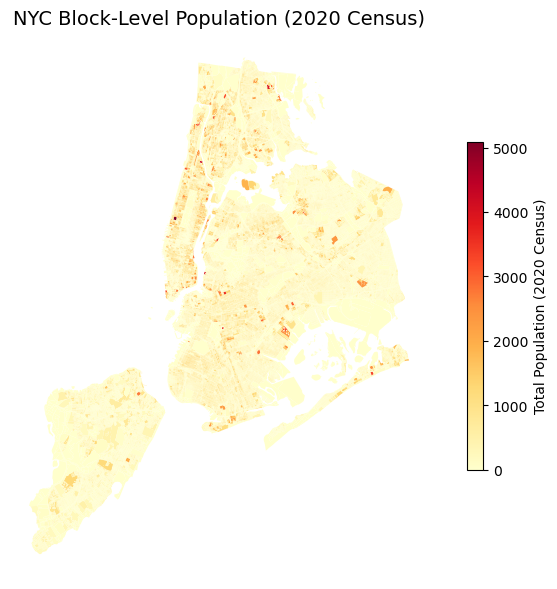

In [11]:
# Map
fig, ax = plt.subplots(figsize=(8, 6))

nyc_pop.plot(
    column="total_pop",
    ax=ax,
    cmap="YlOrRd",
    linewidth=0,
    legend=True,
    legend_kwds={"label": "Total Population (2020 Census)", "shrink": 0.6},
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

ax.set_title("NYC Block-Level Population (2020 Census)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("nyc_block_population_map.png", dpi=150, bbox_inches="tight")
plt.show()

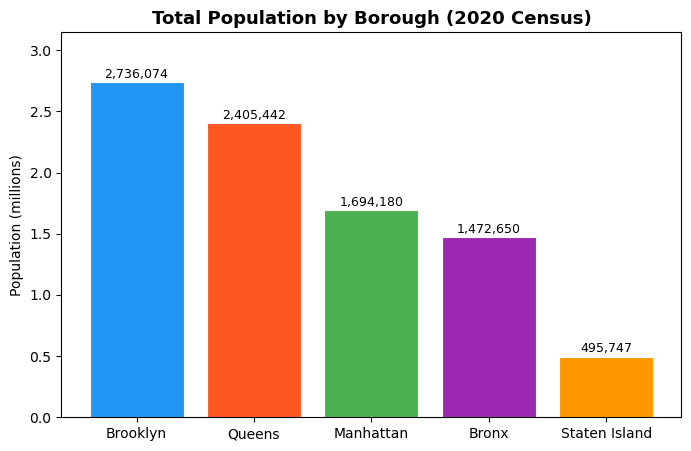

In [12]:
borough_pop = (
    nyc_pop.groupby("borough")["total_pop"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    borough_pop["borough"],
    borough_pop["total_pop"] / 1_000_000,
    color=["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800"],
    edgecolor="white",
    linewidth=0.8,
)

for bar, val in zip(bars, borough_pop["total_pop"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title(
    "Total Population by Borough (2020 Census)", fontsize=13, fontweight="bold"
)
ax.set_ylabel("Population (millions)")
ax.set_ylim(0, borough_pop["total_pop"].max() / 1_000_000 * 1.15)
plt.show()

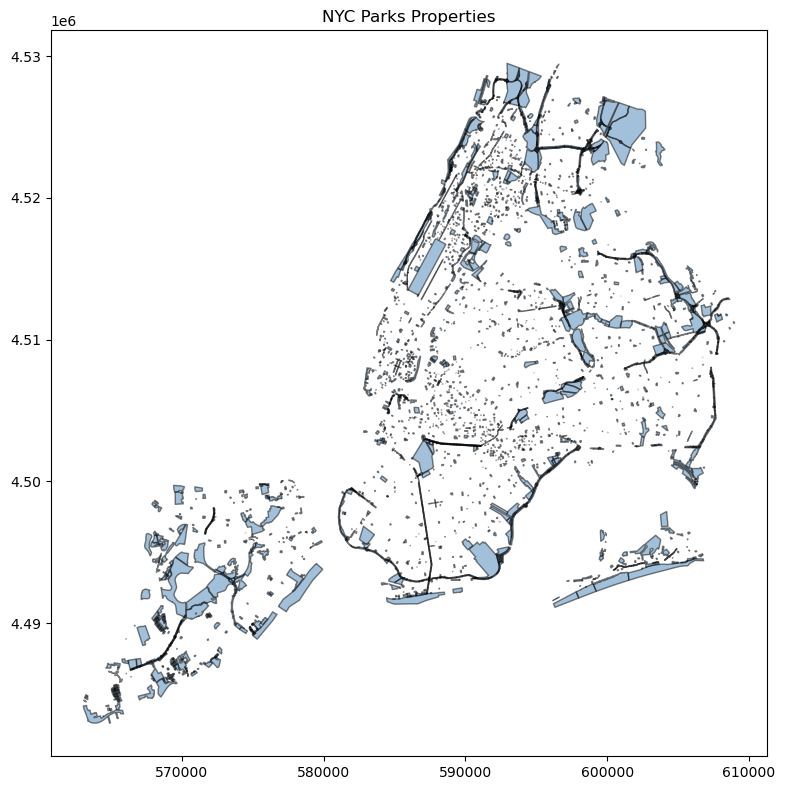

In [13]:
parks_data = gpd.read_file("Parks_Properties_20260416.csv")

parks_data = parks_data.set_geometry(
    gpd.GeoSeries.from_wkt(parks_data["multipolygon"]), crs="EPSG:4326"
)
parks_data = parks_data.to_crs("EPSG:32618")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
parks_data.plot(ax=ax, edgecolor="black", facecolor="steelblue", alpha=0.5)
ax.set_title("NYC Parks Properties")
plt.tight_layout()
plt.show()

In [14]:
nyc_boundary = nyc_blocks.dissolve().to_crs("EPSG:32618")

In [15]:
# creating the rasters from the dataset
resolution = 100  # meters per pixel
minx, miny, maxx, maxy = nyc_boundary.total_bounds
width = int((maxx - minx) / resolution)
height = int((maxy - miny) / resolution)
transform = from_bounds(minx, miny, maxx, maxy, width, height)

# rasters for the parks and the boundaries
park_mask = rasterize(
    shapes=parks_data.geometry,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    default_value=1,
    dtype="uint8",
)

nyc_mask = rasterize(
    shapes=nyc_boundary.geometry,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    default_value=1,
    dtype="uint8",
)

In [16]:
# --- Distance transform ---
parks_distance_meters = distance_transform_edt(1 - park_mask) * resolution
parks_distance_meters[nyc_mask == 0] = np.nan

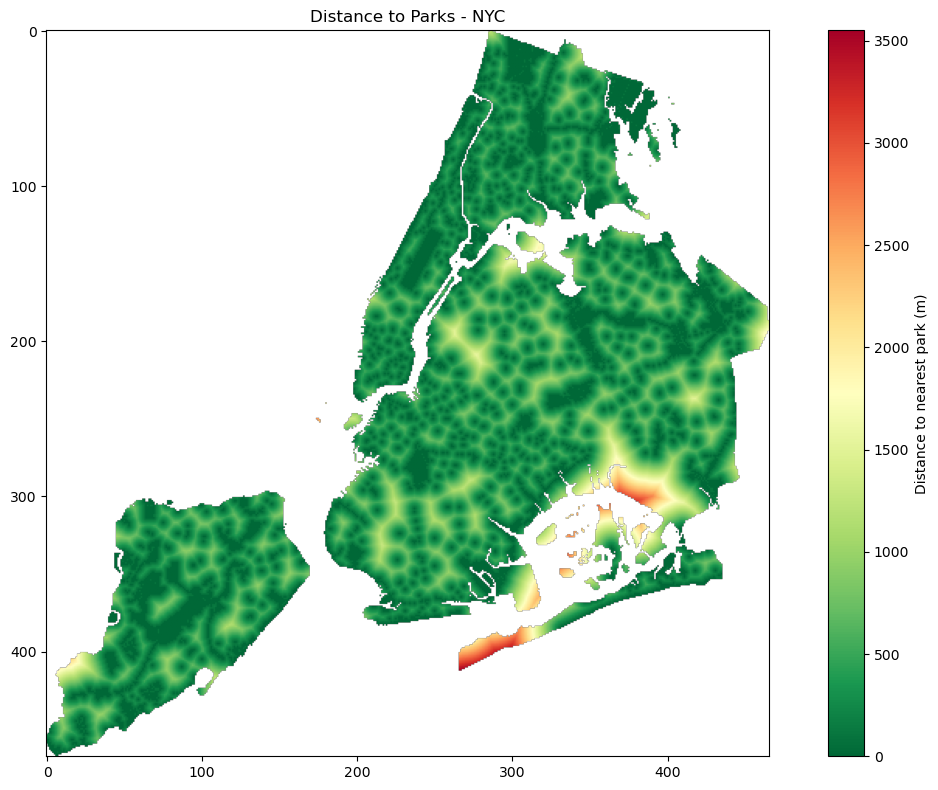

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(parks_distance_meters, cmap="RdYlGn_r")
plt.colorbar(im, ax=ax, label="Distance to nearest park (m)")
ax.set_title("Distance to Parks - NYC")
plt.tight_layout()
plt.show()

In [18]:
with rasterio.open(
    "distance_to_parks.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs="EPSG:32618",
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(parks_distance_meters.astype("float32"), 1)

In [19]:
# Make sure blocks are in the same CRS as the raster
nyc_blocks_utm = nyc_pop.to_crs("EPSG:32618")

# nyc_blocks_utm = nyc_blocks.to_crs("EPSG:32618")

# Compute mean distance to park for each block
stats = zonal_stats(
    nyc_blocks_utm,
    "distance_to_parks.tif",
    stats=["mean", "min", "max"],
    nodata=np.nan,
)

## Creating the min/ mean columns for the distance to parks data

In [20]:
nyc_blocks_utm["mean_dist_to_park"] = [s["mean"] for s in stats]
nyc_blocks_utm["min_dist_to_park"] = [s["min"] for s in stats]

## Calculating the Distance to Water Bodies raster + block statistics

In [21]:
NYC_waterbodies = gpd.read_file("NYC_Hydrography.csv")

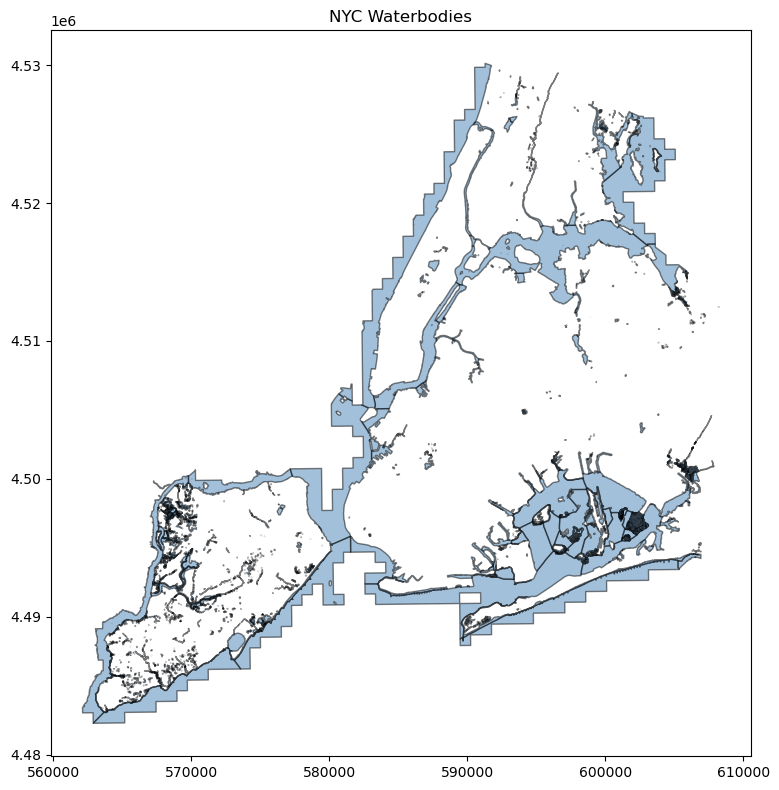

In [22]:
# Set geometry from the WKT multipolygon column
NYC_waterbodies = NYC_waterbodies.set_geometry(
    gpd.GeoSeries.from_wkt(NYC_waterbodies["the_geom"]), crs="EPSG:4326"
)
NYC_waterbodies = NYC_waterbodies.to_crs("EPSG:32618")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
NYC_waterbodies.plot(ax=ax, edgecolor="black", facecolor="steelblue", alpha=0.5)
ax.set_title("NYC Waterbodies")
plt.tight_layout()
plt.show()

In [23]:
# Use the same raster grid as before
water_mask = rasterize(
    shapes=NYC_waterbodies.geometry,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    default_value=1,
    dtype="uint8",
)

# --- Distance transform BEFORE applying NYC mask ---
distance_water_meters = distance_transform_edt(1 - water_mask) * resolution

# --- THEN mask to NYC ---
distance_water_meters[nyc_mask == 0] = np.nan

In [24]:
with rasterio.open(
    "distance_to_water.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs="EPSG:32618",
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(distance_water_meters.astype("float32"), 1)

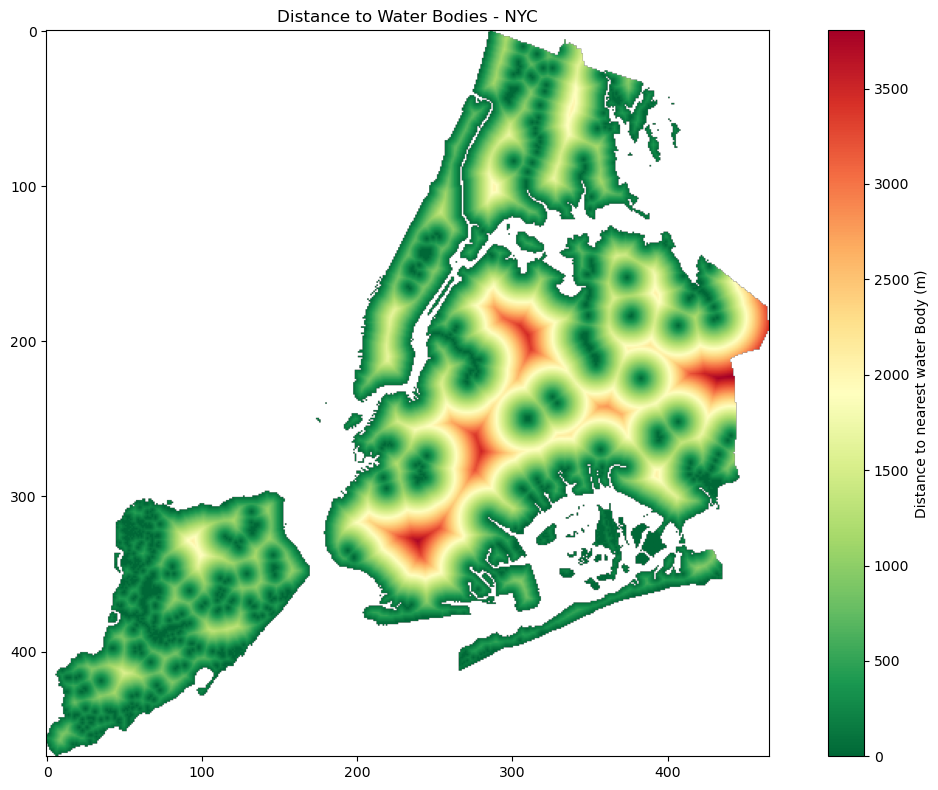

In [25]:
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(distance_water_meters, cmap="RdYlGn_r")
plt.colorbar(im, ax=ax, label="Distance to nearest water Body (m)")
ax.set_title("Distance to Water Bodies - NYC")
plt.tight_layout()
plt.show()

In [26]:
water_stats = zonal_stats(
    nyc_blocks_utm,
    "distance_to_water.tif",
    stats=["mean", "min", "max"],
    nodata=np.nan,
)

nyc_blocks_utm["mean_dist_to_water"] = [sw["mean"] for sw in water_stats]
nyc_blocks_utm["min_dist_to_water"] = [sw["min"] for sw in water_stats]

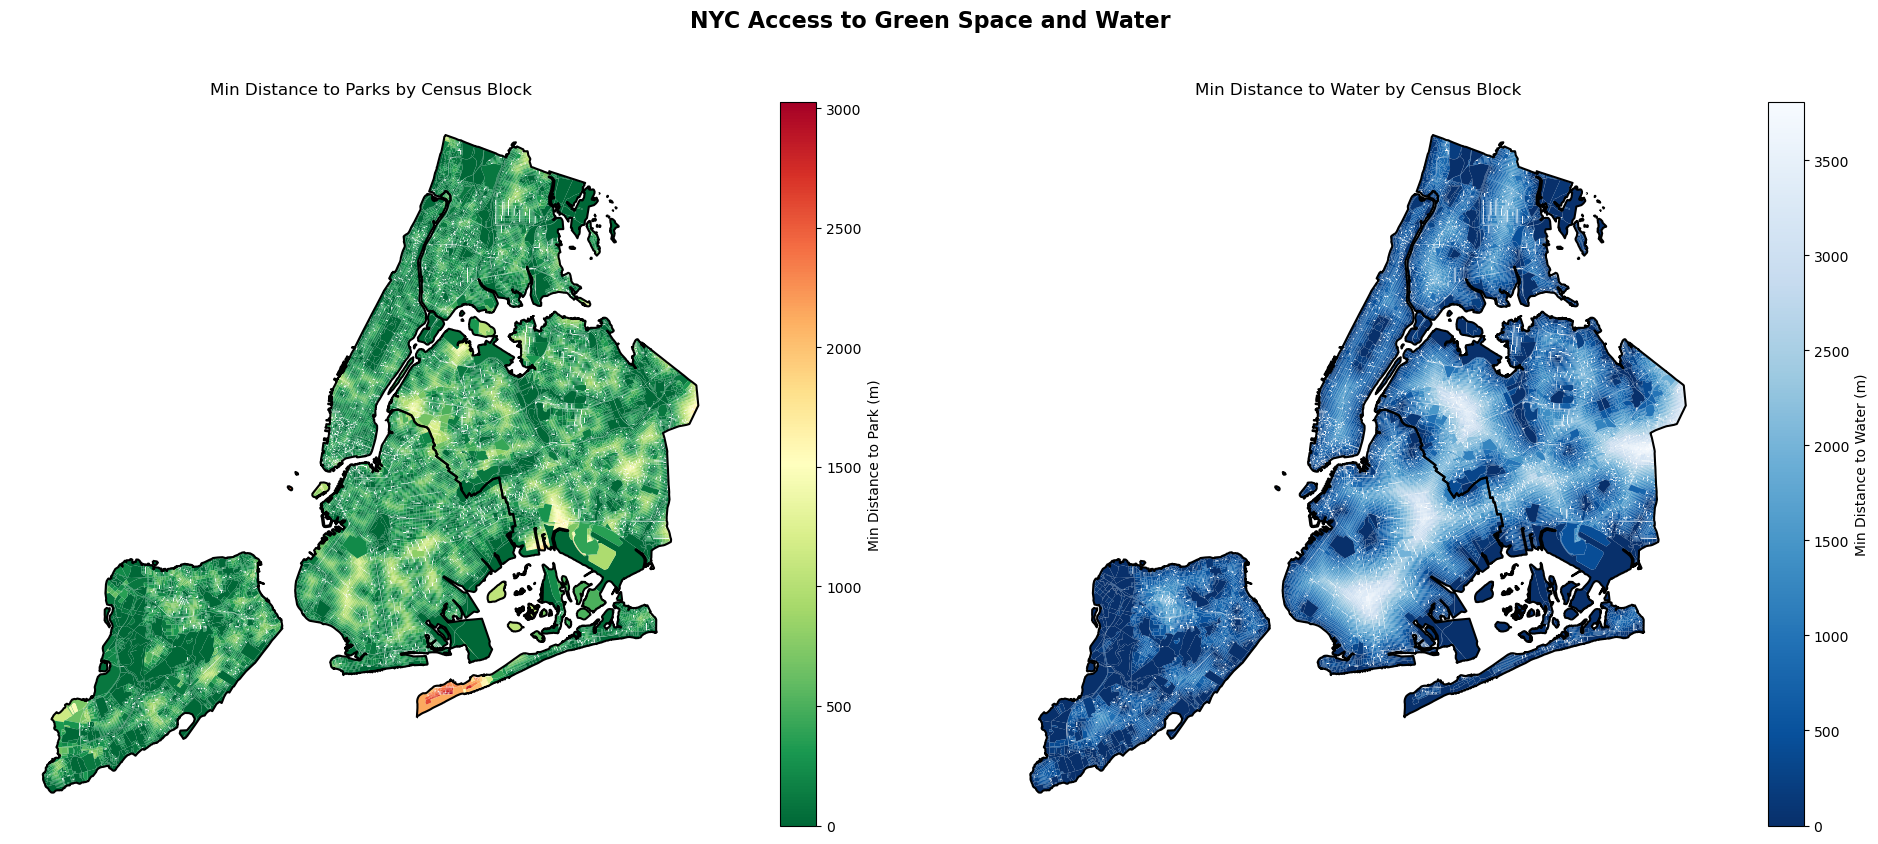

In [27]:
nyc_boroughs_utm = nyc_blocks.dissolve(by="borough").to_crs("EPSG:32618")


fig, axes = plt.subplots(1, 2, figsize=(20, 8))

nyc_blocks_utm.plot(
    column="min_dist_to_park",
    ax=axes[0],
    cmap="RdYlGn_r",
    legend=True,
    legend_kwds={"label": "Min Distance to Park (m)"},
)
nyc_boroughs_utm.boundary.plot(ax=axes[0], edgecolor="black", linewidth=1.5)
axes[0].set_title("Min Distance to Parks by Census Block")
axes[0].set_axis_off()

nyc_blocks_utm.plot(
    column="min_dist_to_water",
    ax=axes[1],
    cmap="Blues_r",
    legend=True,
    legend_kwds={"label": "Min Distance to Water (m)"},
)
nyc_boroughs_utm.boundary.plot(ax=axes[1], edgecolor="black", linewidth=1.5)
axes[1].set_title("Min Distance to Water by Census Block")
axes[1].set_axis_off()

plt.suptitle(
    "NYC Access to Green Space and Water", fontsize=16, fontweight="bold", y=1.05
)
plt.tight_layout()
plt.show()

change parks to buildings

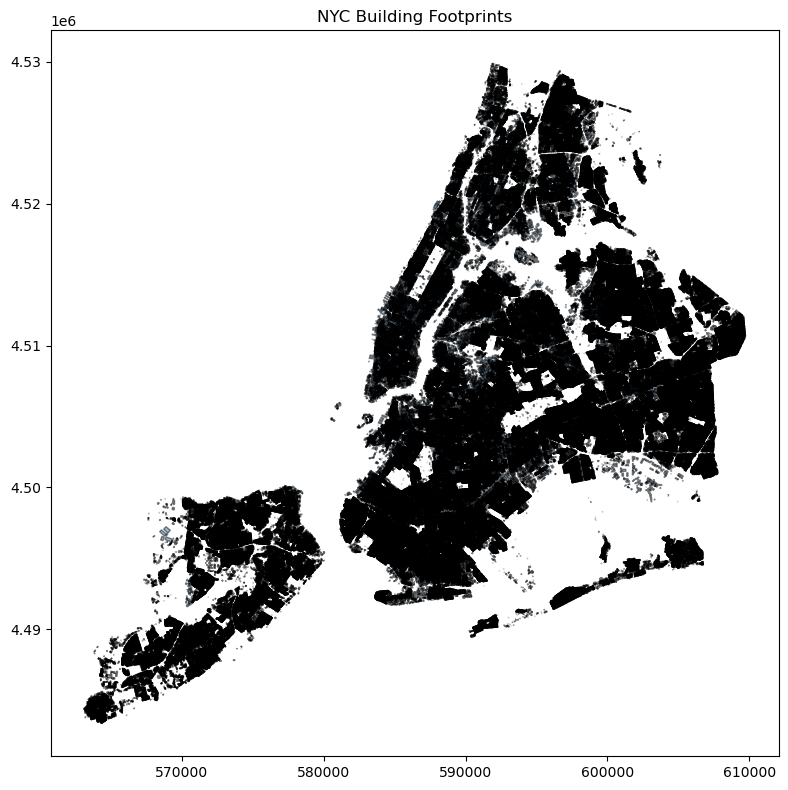

In [28]:
buildings_data = gpd.read_file("BUILDING_20260428.csv")

buildings_data = buildings_data.set_geometry(
    gpd.GeoSeries.from_wkt(buildings_data["the_geom"]), crs="EPSG:4326"
)
buildings_data = buildings_data.to_crs("EPSG:32618")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
buildings_data.plot(ax=ax, edgecolor="black", facecolor="steelblue", alpha=0.5)
ax.set_title("NYC Building Footprints")
plt.tight_layout()
plt.show()

In [29]:
resolution = 100  # meters per pixel
minx, miny, maxx, maxy = nyc_boundary.total_bounds
width = int((maxx - minx) / resolution)
height = int((maxy - miny) / resolution)
transform = from_bounds(minx, miny, maxx, maxy, width, height)

# rasters for the parks and the boundaries
buildings_mask = rasterize(
    shapes=buildings_data.geometry,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    default_value=1,
    dtype="uint8",
)

nyc_mask = rasterize(
    shapes=nyc_boundary.geometry,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    default_value=1,
    dtype="uint8",
)

In [30]:
# --- Distance transform ---
buildings_distance_meters = distance_transform_edt(1 - buildings_mask) * resolution
buildings_distance_meters[nyc_mask == 0] = np.nan

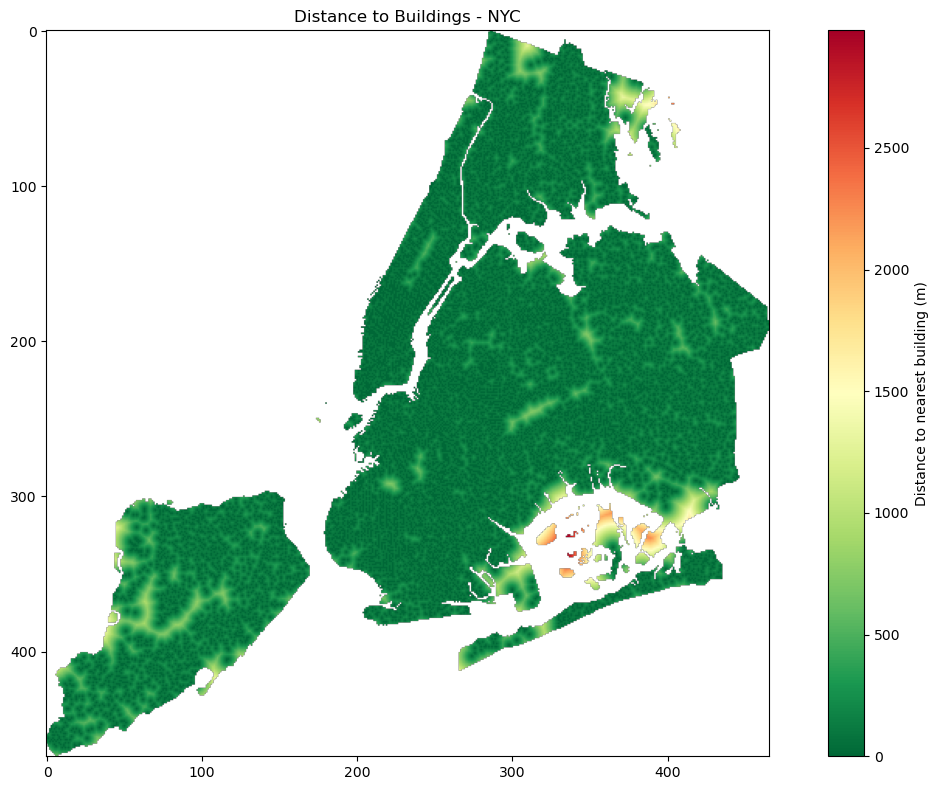

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(buildings_distance_meters, cmap="RdYlGn_r")
plt.colorbar(im, ax=ax, label="Distance to nearest building (m)")
ax.set_title("Distance to Buildings - NYC")
plt.tight_layout()
plt.show()

In [32]:
with rasterio.open(
    "distance_to_buildings.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs="EPSG:32618",
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(buildings_distance_meters.astype("float32"), 1)

In [33]:
building_stats = zonal_stats(
    nyc_blocks_utm,
    "distance_to_buildings.tif",
    stats=["mean", "min"],
    nodata=np.nan,
)

nyc_blocks_utm["mean_dist_to_buildings"] = [sb["mean"] for sb in building_stats]
nyc_blocks_utm["min_dist_to_buildings"] = [sb["min"] for sb in building_stats]

In [34]:
nyc_blocks_utm.to_csv("NYC_block_combined_data.csv", sep=",")